# 4.9 IC Intro to data visualization with Python

# Table of Contents

#### 01. Import libraries

#### 02. Create a bar chart

#### 03. Create a histogram

#### 04. Create a line chart

# 01. Import libraries

In [3]:
# Import libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

__Note the addition of 3 visualization-related libraries that were imported (above), and use of their abbreviations for code simplicity__

In [6]:
# Import ords_prods_merge_6 dataframe

path = r'C:\Users\dirk8\CareerFoundry Projects\03-2025 Instacart Basket Analysis'
ords_prods_merge = pd.read_pickle(os.path.join(path, 'Data', 'Prepared Data', 'ords_prods_merge_6.pkl'))

# 02. Create a Bar Chart

<Axes: xlabel='orders_day_of_week'>

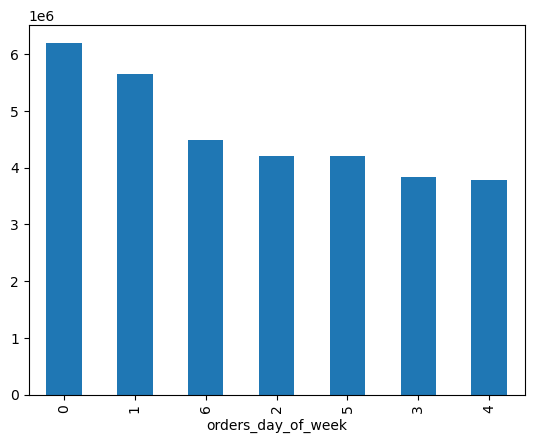

In [24]:
# Create a bar chart for 'orders_day_of_week'
# Note that by not assigning it to a variable, this gives a preview of the visualization but does not save it to jupyter's memory

ords_prods_merge['orders_day_of_week'].value_counts().plot.bar()

<Axes: xlabel='orders_day_of_week'>

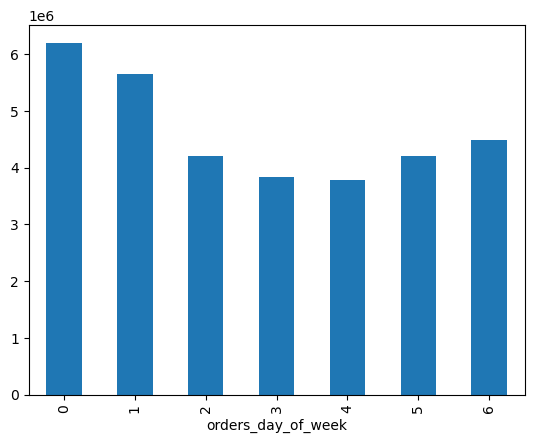

In [10]:
# Sort the bar chart by the x-axis index values rather than descending y-axis magnitudes

ords_prods_merge['orders_day_of_week'].value_counts().sort_index().plot.bar()

__Note: this index sorting also works well for frequency distributions, as below__

In [14]:
# Output an index-sorted frequency distribution rather than descending count-sorted

ords_prods_merge['orders_day_of_week'].value_counts().sort_index()

orders_day_of_week
0    6203329
1    5659298
2    4213105
3    3839865
4    3783172
5    4205076
6    4495887
Name: count, dtype: int64

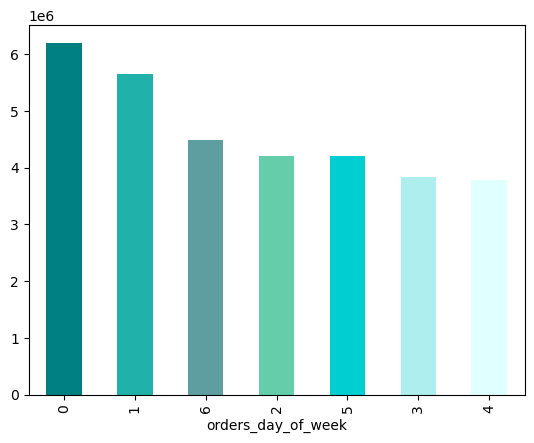

In [26]:
# Let's add colors to the bar chart
# Setting it to a variable (as an object) saves it in jupyter's memory so that it is exportable

bar = ords_prods_merge['orders_day_of_week'].value_counts().plot.bar(color = ['teal', 'lightseagreen', 'cadetblue', 'mediumaquamarine', 'darkturquoise', 'paleturquoise', 'lightcyan'])

__You can access a saved chart (to variable_name) at any time by using:  variable_name.figure.  To export it outside of Jupyter in the form of an image file, you use the figure.savefig() function, where the path the image is saved to goes within the parentheses.__

In [30]:
# Export the bar chart image using figure.savefig()

bar.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'bar_orders_dow.png'))

# 03. Create a Histogram

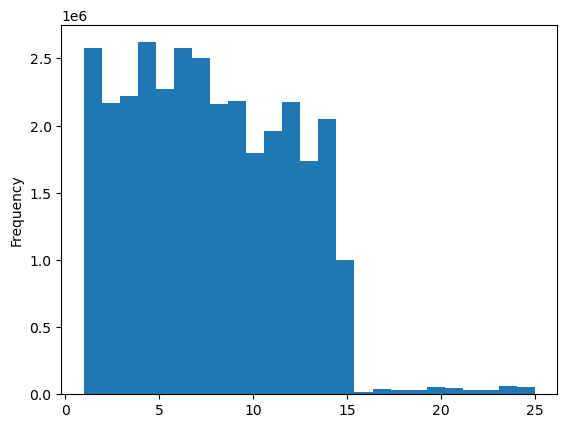

In [43]:
# Create a histogram
# Note that unlike the bar chart, the histogram creation syntax does not require a frequency distribution .value_counts() function in the line of code

hist = ords_prods_merge['prices'].plot.hist(bins = 25)

__NOTE: Because I removed key outliers in the 'prices' column BEFORE this exercise 4.9, the exercise has some example steps I cannot reproduce so this writeup here explains them.  In the Exercise, the histogram example gave a single line, which flagged the presence of outliers distorting the result.  To find these, a scatterplot on 'prices' where both x-axis and y-axis used the 'prices' column data was used to locate the outliers, as follows: sns.scatterplot(x = 'prices', y = 'prices',data = ords_prods_merge).  This Exercise 4.9 resulting scatterplot shows 3 dots, one close to zero, one close to 20000 and one dot close to 100000. Latter two are the outliers. To look for and explore outliers more granularly at this stage, for this dataframe use: ords_prods_merge.loc[ords_prods_merge['prices'] > 100], which ends up showing a 5127 x 14 table with 14900 and 99999 values for 'prices'. Exercise 4.9 suggests turning the outliers into NaN values (missing values), as follows: ords_prods_merge.loc[ords_prods_merge['prices'] >100, 'prices'] = np.nan.  I will not do this because I already deleted those values from the dataframe on a previous cleaning, although only after creating an a 5127-row subset dataframe and exporting them into a backup (outliers content) file.__

In [39]:
# Check max value in the 'prices' column to ensure no outliers present

ords_prods_merge['prices'].max()

25.0

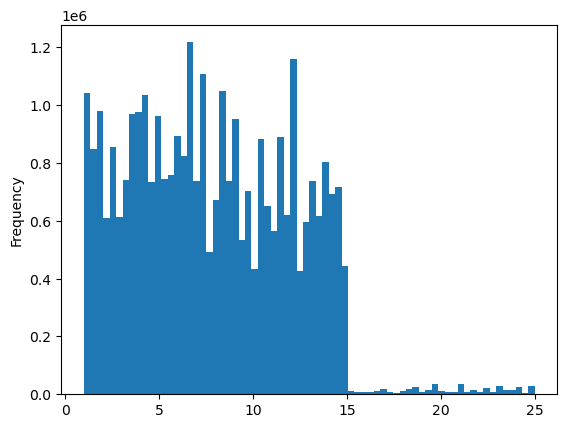

In [41]:
# Create a more granular histogram by increasing bins to 70 (from 25)

hist_2 = ords_prods_merge['prices'].plot.hist(bins = 70)

__Export the histogram__

In [46]:
# Export the histogram

hist_2.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'histogram_prices.png'))

# 04. Create a Line Chart

__Line charts, especially for our dataframe, use a lot of RAM.  Consequently, we need to create smaller subset dfs but based off randomized row selection for inclusion, to get a representative sample of the population.  This will show how the randomized samples are created, one can choose a 70/30 or 80/20 split in creating 2 samples.__

__SAMPLING DATA__

In [51]:
# We start by creating a seed for the random number generator, which can be any number
# Whatever number is chosen for the seed is used in the future to get the exact sequence of random numbers generated, for reproducibility purposes
# The random number generator (the function np.random.rand()) generates random numbers between 0 and 1
# The next line creates a list of boolean True/False values based on comparing the generated random numbers to 0.7 (proportion of df for one sample)
# This boolean list is assigned to a variable ("dev" in this example)

np.random.seed(4)
dev = np.random.rand(len(ords_prods_merge)) <= 0.7

In [71]:
# Check the output
dev

array([False,  True, False, ..., False,  True,  True])

In [73]:
# Check length
len(dev)

32399732

In [75]:
# Now we need to create 2 sample subset dfs using the created boolean list assigned to "dev"
# Store 70% of the sample in the dataframe big
# When you pass a variable containing a list of boolean values to the square brackets of a Pandas dataframe ...
# (cont.) ... it performs boolean indexing, selecting only the rows where the corresponding boolean value in the list is True

big = ords_prods_merge[dev]

In [79]:
# Store 30% of the sample in the dataframe small
# The tilde (~) means "not" whatever comes after, e.g. False (so here, it takes the False boolean values, which should make up 30% of the list

small = ords_prods_merge[~dev]

In [81]:
# Check length of population dataframe
len(ords_prods_merge)

32399732

In [83]:
# Check whether the lengths of the 70/30 sample subset dfs add up to match the length of the population df

len(big) + len(small)

32399732

In [85]:
# Save RAM further by creating a much smaller subset df with only the 2 variables needed to create the line chart

df_2 = small[['orders_day_of_week', 'prices']]

In [89]:
# Check the output
df_2.head(3)

,orders_day_of_week,prices
0,2,9.0
2,2,4.4
3,2,4.7


In [91]:
# Check the dimensions
df_2.shape

(9719609, 2)

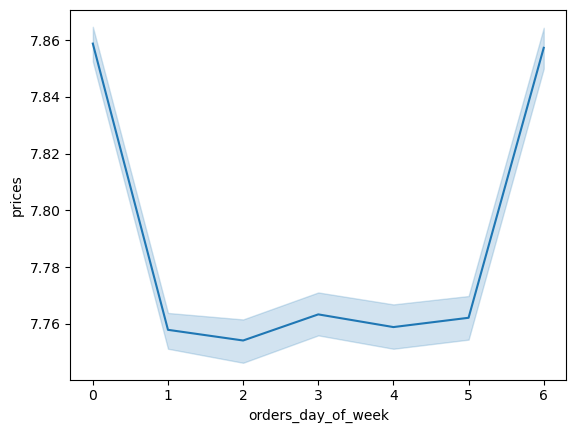

In [93]:
# Now we can create the line chart

line = sns.lineplot(data = df_2, x = 'orders_day_of_week', y = 'prices')

In [95]:
# Export the line chart

line.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'line_prices.png'))

__Comment: No need to export the dataframe because it was not modified.__